In [1]:
from matplotlib import pyplot as plt
import numpy as np
import joblib
import os
from dataset import load_dataset
from src.classification.mlp_fault_classifier import MLPFaultClassifier
import pandas as pd
from sklearn.inspection import permutation_importance
plt.style.use("default")
from plot_style import set_plot_style
set_plot_style()

In [2]:
TRAIN_PATH_FULL = "../../../data/processed/full_train/train.csv"
TRAIN_PATH_SPLIT = "../../../data/processed/split_85_15/train_85.csv"
TEST_PATH_SPLIT  = "../../../data/processed/split_85_15/test_15.csv"
TEST_PATH_PREDICT  = "../../../data/processed/split_85_15/test_15.csv"
OUTPUT_PATH="../../../output/MLP/"
OUTPUT_PATH_PR="../../../output/polynomial_regression/model_target/"
OUTPUT_PATH_RF= "../../../output/random_forest_regressor/model_target/"
OUTPUT_PATH_GPR= "../../../output/GPR/model_target/"
MODEL_PATH = "mlp.pkl"
TARGET_COL = "faulty"
FEUTURE=["trq_margin","oat","pa","np_ng_ratio","ias","mgt"]
FEUTURE_PREDICT=["trq_margin_pred","oat","pa","np_ng_ratio","ias","mgt"]

In [3]:
train_df=load_dataset(TRAIN_PATH_SPLIT)
test_df=load_dataset(TEST_PATH_SPLIT)
test_df_predict_PR=load_dataset(OUTPUT_PATH_PR+"pred_margin_test.csv")
test_df_predict_RF=load_dataset(OUTPUT_PATH_RF+"pred_margin_test.csv")
test_df_predict_GPR=load_dataset(OUTPUT_PATH_GPR+"pred_margin_test.csv")

X_train = train_df[FEUTURE].values
y_train = train_df[TARGET_COL].values

X_test = test_df[FEUTURE].values
y_test= test_df[TARGET_COL].values

X_test_predict_PR = test_df_predict_PR[FEUTURE_PREDICT].values
y_test_predict_PR= test_df_predict_PR[TARGET_COL].values

X_test_predict_RF = test_df_predict_RF[FEUTURE_PREDICT].values
y_test_predict_RF= test_df_predict_RF[TARGET_COL].values

X_test_predict_GPR = test_df_predict_GPR[FEUTURE_PREDICT].values
y_test_predict_GPR= test_df_predict_GPR[TARGET_COL].values

In [8]:
mlp=MLPFaultClassifier(hidden_layer_sizes=(128,64,24))
if os.path.exists(OUTPUT_PATH+MODEL_PATH):
    mlp=joblib.load(OUTPUT_PATH + MODEL_PATH)
else:
    mlp.fit(X_train,y_train)
    joblib.dump(mlp, OUTPUT_PATH + MODEL_PATH)

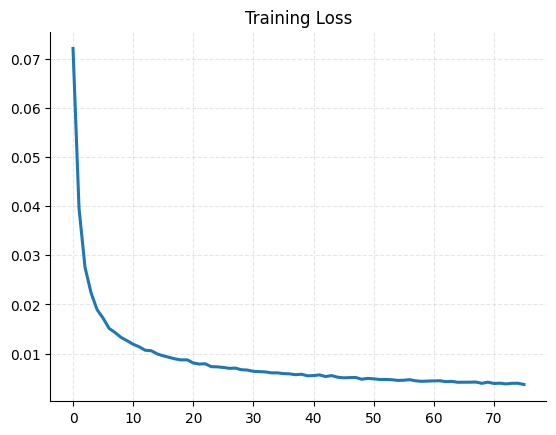

In [9]:
r=mlp.model.named_steps["mlp"]
plt.plot(r.loss_curve_)
plt.title("Training Loss")
plt.show()

Accuracy: 0.9990
F1 macro: 0.9990

Confusion Matrix:
[[66421    60]
 [   49 44864]]

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     66481
           1       1.00      1.00      1.00     44913

    accuracy                           1.00    111394
   macro avg       1.00      1.00      1.00    111394
weighted avg       1.00      1.00      1.00    111394



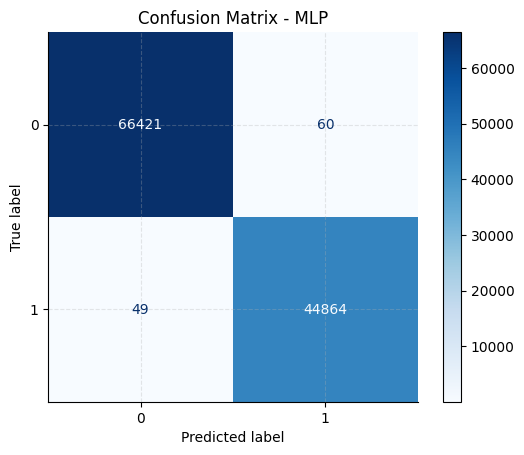

{'accuracy': 0.999021491283193,
 'f1_macro': 0.9989834202648883,
 'confusion_matrix': array([[66421,    60],
        [   49, 44864]])}

In [10]:
mlp.evaluate(X_test,y_test)

In [31]:
mean_score, scores = mlp.evaluate_phm_score(X_test, y_test)
print(np.min(scores), np.max(scores))

worst_idx = np.argmin(scores)
best_idx  = np.argmax(scores)

print("peggior score:", scores[worst_idx], "at index:", worst_idx)
print("miglior score :", scores[best_idx],  "at index:", best_idx)

PHM score (mean): 0.9968
-4.973674366334204 1.0
peggior score: -4.973674366334204 at index: 6105
miglior score : 1.0 at index: 1


In [32]:
idx=27565
test_X = test_df.loc[[idx], FEUTURE]
test_y = test_df.loc[idx, TARGET_COL]
y_pred = mlp.predict(test_X)
print("True class:", test_y)
print("Pred class:", y_pred)
print("confidence:", np.max(mlp.model.predict_proba(test_X)))


True class: 1
Pred class: [1]
confidence: 0.8713144514241271


/Users/alessandropettinaro/PycharmProjects/PHM_2024_Project/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/Users/alessandropettinaro/PycharmProjects/PHM_2024_Project/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [9]:
r = permutation_importance(
    mlp.model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_imp = pd.Series(r.importances_mean, index=FEUTURE)\
             .sort_values(ascending=False)

print(perm_imp.head(10))

trq_margin     0.317031
oat            0.195101
np_ng_ratio    0.172399
pa             0.118527
mgt            0.075000
ias            0.054151
dtype: float64


Test with trq_margin predict from model Polynomial regressor

Accuracy: 0.9990
F1 macro: 0.9990

Confusion Matrix:
[[66421    60]
 [   51 44862]]

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     66481
           1       1.00      1.00      1.00     44913

    accuracy                           1.00    111394
   macro avg       1.00      1.00      1.00    111394
weighted avg       1.00      1.00      1.00    111394



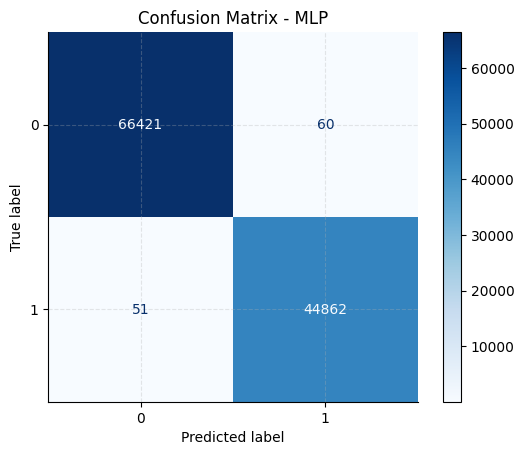

{'accuracy': 0.9990035369948113,
 'f1_macro': 0.998964759951547,
 'confusion_matrix': array([[66421,    60],
        [   51, 44862]])}

In [11]:
mlp.evaluate(X_test_predict_PR,y_test_predict_PR)

Test with trq_margin predict from model Random forest  regressor

Accuracy: 0.9990
F1 macro: 0.9989

Confusion Matrix:
[[66421    60]
 [   55 44858]]

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     66481
           1       1.00      1.00      1.00     44913

    accuracy                           1.00    111394
   macro avg       1.00      1.00      1.00    111394
weighted avg       1.00      1.00      1.00    111394



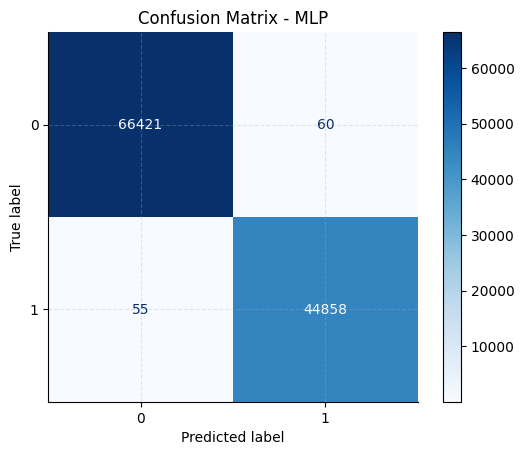

{'accuracy': 0.9989676284180476,
 'f1_macro': 0.9989274385143561,
 'confusion_matrix': array([[66421,    60],
        [   55, 44858]])}

In [12]:
mlp.evaluate(X_test_predict_RF,y_test_predict_RF)

Accuracy: 0.9990
F1 macro: 0.9990

Confusion Matrix:
[[66420    61]
 [   50 44863]]

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     66481
           1       1.00      1.00      1.00     44913

    accuracy                           1.00    111394
   macro avg       1.00      1.00      1.00    111394
weighted avg       1.00      1.00      1.00    111394



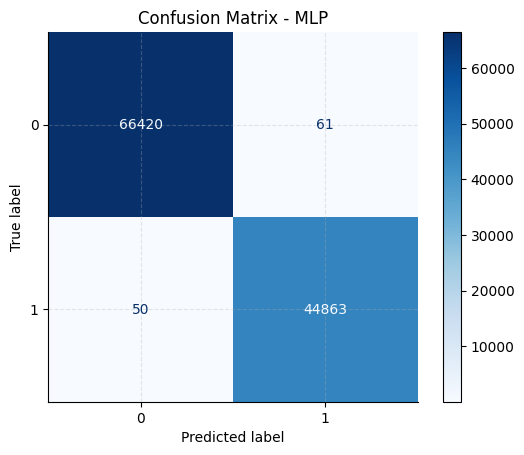

{'accuracy': 0.9990035369948113,
 'f1_macro': 0.9989647674257119,
 'confusion_matrix': array([[66420,    61],
        [   50, 44863]])}

In [13]:
mlp.evaluate(X_test_predict_GPR,y_test_predict_GPR)